# 基于 MedformerFFT 的 PTB-XL 心电图分类

**基线 Medformer 复现**  
**时域与频域联合表征学习**  
**FFT / DCT 消融实验**  
**鲁棒性评估**




## 1. 项目概述

本项目把 PTB-XL 心电图分类视为医学时间序列分类问题。基线模型是 Medformer，它使用多粒度分片的变换器结构处理医学时间序列。扩展模型加入显式频域特征：MedformerFFT 使用 FFT 幅值特征，MedformerDCT 使用 DCT 系数；如果仓库中存在门控融合、双线性融合和交叉注意力等变体，也会一并纳入整理。

本实验使用的核心模型变体：

- **基线 / 仅时域**：`models/Medformer.py`，时域 Medformer 编码器加分类头。
- **仅 FFT**：`models/FrequencyOnly.py`，或 `models/MedformerFFT.py` 中的 `FrequencyOnlyModel`，只使用频域特征，不使用时域分支。
- **时域 + FFT**：`models/MedformerFFT.py`，先拼接时域分支和 FFT 幅值分支，再进行分类。
- **DCT**：当 SciPy 可用时，使用 `models/MedformerDCT.py` 和 `models/DCTOnly.py`。



## 2. 环境与可复现性

记录运行环境、可选依赖版本、当前工作目录、git 提交信息和确定性随机种子配置。


In [1]:
from pathlib import Path
import json
import os
import platform
import random
import re
import sys
import time

# Project bootstrap: keep the notebook runnable from a fresh kernel.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "Medformer" / "Medformer-main").exists():
    for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (parent / "Medformer" / "Medformer-main").exists():
            PROJECT_ROOT = parent.resolve()
            break
MEDFORMER_ROOT = PROJECT_ROOT / "Medformer" / "Medformer-main"
# Fallbacks for different directory layouts
if not MEDFORMER_ROOT.exists():
    MEDFORMER_ROOT = PROJECT_ROOT / "Medformer-main"
if not MEDFORMER_ROOT.exists():
    MEDFORMER_ROOT = PROJECT_ROOT / "formal_code" / "Medformer-main"
# Fallback: code may be directly under Medformer-main/ (no Medformer/ wrapper)
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "notebook"
FIGURE_ROOT = PROJECT_ROOT / "notebooks" / "notebook_figures"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

import importlib, subprocess
versions = {
    "python": sys.version.replace("\n", " "),
    "platform": platform.platform(),
}
for pkg in ["numpy", "pandas", "matplotlib", "sklearn", "torch", "scipy", "wfdb", "nbformat"]:
    try:
        mod = importlib.import_module(pkg)
        versions[pkg] = getattr(mod, "__version__", "installed")
    except Exception as exc:
        versions[pkg] = f"not available ({type(exc).__name__})"

try:
    import torch
    versions["cuda_available"] = torch.cuda.is_available()
    versions["cuda_version"] = getattr(torch.version, "cuda", None)
    versions["gpu"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only"
except Exception:
    versions["cuda_available"] = False
    versions["gpu"] = "torch unavailable"

try:
    commit = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd=PROJECT_ROOT, text=True).strip()
except Exception as exc:
    commit = f"unavailable ({type(exc).__name__})"
versions["git_commit"] = commit
versions["cwd"] = str(Path.cwd())

SEED = 42
random.seed(SEED)
try:
    import numpy as np
    np.random.seed(SEED)
except Exception:
    pass
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
except Exception:
    pass

for k, v in versions.items():
    print(f"{k}: {v}")

for req in [MEDFORMER_ROOT / "requirements.txt", PROJECT_ROOT / "requirements.txt"]:
    if req.exists():
        print(f"\nRequirements from {req.relative_to(PROJECT_ROOT)}:")
        print(req.read_text(encoding="utf-8", errors="replace")[:4000])

print("\nOptional install cell, intentionally not executed by default:")
print("# %pip install -r formal_code/Medformer-main/requirements.txt")


D:\Anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\Anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


python: 3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
platform: Windows-11-10.0.26200-SP0
numpy: 1.26.4
pandas: 3.0.3
matplotlib: 3.8.2
sklearn: 1.4.0
torch: 2.5.1+cu121
scipy: 1.17.1
wfdb: 4.3.1
nbformat: 5.10.4
cuda_available: True
cuda_version: 12.1
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
git_commit: unavailable (CalledProcessError)
cwd: E:\deeplearning\ecg_time_frequency_dual_branch_classification

Requirements from Medformer\Medformer-main\requirements.txt:
einops~=0.5.0
matplotlib==3.7.0
numpy==1.23.5
pandas==1.5.3
patool==1.12
reformer-pytorch==1.4.4
scikit-learn==1.2.2
scipy==1.10.1
sktime==0.16.1
sympy==1.11.1
torch~=2.0.0+cu118
tqdm==4.64.1
natsort~=8.4.0

Optional install cell, intentionally not executed by default:
# %pip install -r Medformer/Medformer-main/requirements.txt


## 3. 自动路径检测与配置

路径会相对于自动识别出的项目根目录进行解析。日志中的服务器绝对路径只作为证据字符串保留；可执行单元统一使用项目相对路径。


In [2]:
DATA_CANDIDATES = [
    MEDFORMER_ROOT / "dataset" / "PTB-XL",
    MEDFORMER_ROOT / "dataset" / "PTB-XL-Partial",
    PROJECT_ROOT / "data" / "ptb_xl",
    PROJECT_ROOT / "data" / "ptb_xl" / "raw_partial" / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.2",
]
RESULT_CANDIDATES = [PROJECT_ROOT / "results", MEDFORMER_ROOT / "results"]
LOG_CANDIDATES = [PROJECT_ROOT / "results" / "logs", MEDFORMER_ROOT / "logs"]
CHECKPOINT_CANDIDATES = [MEDFORMER_ROOT / "checkpoints", PROJECT_ROOT / "checkpoints"]
FIGURE_CANDIDATES = [PROJECT_ROOT / "notebooks" / "notebook_figures", PROJECT_ROOT / "Paper" / "pic", PROJECT_ROOT / "pictures_referrence"]

def existing(paths):
    return [p for p in paths if p.exists()]

paths_status = {
    "data": [str(p.relative_to(PROJECT_ROOT)) for p in existing(DATA_CANDIDATES)],
    "results": [str(p.relative_to(PROJECT_ROOT)) for p in existing(RESULT_CANDIDATES)],
    "logs": [str(p.relative_to(PROJECT_ROOT)) for p in existing(LOG_CANDIDATES)],
    "checkpoints": [str(p.relative_to(PROJECT_ROOT)) for p in existing(CHECKPOINT_CANDIDATES)],
    "figures": [str(p.relative_to(PROJECT_ROOT)) for p in existing(FIGURE_CANDIDATES)],
}
print(json.dumps(paths_status, ensure_ascii=False, indent=2))

RUN_SMOKE_TEST = True
RUN_FULL_TRAINING = False
USE_SYNTHETIC_DEMO_WHEN_DATA_MISSING = True


{
  "data": [
    "Medformer\\Medformer-main\\dataset\\PTB-XL",
    "Medformer\\Medformer-main\\dataset\\PTB-XL-Partial",
    "data\\ptb_xl",
    "data\\ptb_xl\\raw_partial\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.2"
  ],
  "results": [
    "results",
    "Medformer\\Medformer-main\\results"
  ],
  "logs": [
    "results\\logs",
    "Medformer\\Medformer-main\\logs"
  ],
  "checkpoints": [
    "Medformer\\Medformer-main\\checkpoints",
    "checkpoints"
  ],
  "figures": [
    "notebooks\\notebook_figures",
    "Paper\\pic",
    "pictures_referrence"
  ]
}


## 4. PTB-XL 数据检查

`PTB-XL` 的项目数据加载器注册在 `data_provider/data_factory.py` 中。训练加载器期望处理后的 NumPy 特征位于 `Feature/`，标签位于 `Label/label.npy`，并生成批次、时间步、通道顺序的张量，即 `(B, T, C)`。如果处理后的数据不存在，切换到与模型输入形状一致的合成演示批次，并明确标注其为合成数据。


In [3]:
import pandas as pd
import numpy as np

def source_snippet(path, pattern, n_after=80):
    path = Path(path)
    if not path.exists():
        return f"missing: {path}"
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    for i, line in enumerate(lines):
        if pattern in line:
            return "\n".join(f"{j+1:04d}: {lines[j]}" for j in range(i, min(len(lines), i+n_after)))
    return f"pattern not found: {pattern}"

print("data_factory registration:")
print(source_snippet(MEDFORMER_ROOT / "data_provider" / "data_factory.py", '"PTB-XL"', 45))
print("\nPTBXLLoader source:")
print(source_snippet(MEDFORMER_ROOT / "data_provider" / "data_loader.py", "class PTBXLLoader", 120))

processed_ptbxl = MEDFORMER_ROOT / "dataset" / "PTB-XL"
feature_dir = processed_ptbxl / "Feature"
label_file = processed_ptbxl / "Label" / "label.npy"
data_available = feature_dir.exists() and label_file.exists() and any(feature_dir.glob("*.npy"))
print(f"\nProcessed PTB-XL available: {data_available}")

CLASS_ABBR = ["NORM", "MI", "STTC", "CD", "HYP"]
synthetic_mode = not data_available
if data_available:
    labels = np.load(label_file)
    feature_files = sorted(feature_dir.glob("*.npy"))
    sample = np.load(feature_files[0])
    print("label.npy shape:", labels.shape)
    print("first feature file:", feature_files[0].relative_to(PROJECT_ROOT), "shape:", sample.shape)
else:
    print("Processed Feature/*.npy and Label/label.npy were not found. Synthetic demo mode will be used for model forward cells.")

SEQ_LEN = 250
ENC_IN = 12
NUM_CLASS = 5
BATCH_SIZE_DEMO = 8
x_demo = np.random.default_rng(SEED).normal(0, 1, size=(BATCH_SIZE_DEMO, SEQ_LEN, ENC_IN)).astype("float32")
y_demo = np.arange(BATCH_SIZE_DEMO) % NUM_CLASS
print("Demo batch shape:", x_demo.shape, "label shape:", y_demo.shape, "synthetic:", synthetic_mode)


data_factory registration:
0023:     "PTB-XL": PTBXLLoader,  # dataset PTB-XL
0024:     "PTB-XL-Partial": PTBXLLoader,  # partial PTB-XL sanity-check dataset
0025:     "FLAAP": FLAAPLoader,  # dataset FLAAP
0026:     "UCI-HAR": UCIHARLoader,  # dataset HAR
0027: }
0028: 
0029: 
0030: def data_provider(args, flag):
0031:     Data = data_dict[args.data]
0032:     timeenc = 0 if args.embed != "timeF" else 1
0033: 
0034:     if flag == "test":
0035:         shuffle_flag = False
0036:         drop_last = True
0037:         if args.task_name == "anomaly_detection" or args.task_name == "classification":
0038:             batch_size = args.batch_size
0039:         else:
0040:             batch_size = 1  # bsz=1 for evaluation
0041:         freq = args.freq
0042:     else:
0043:         shuffle_flag = True
0044:         drop_last = True
0045:         batch_size = args.batch_size  # bsz for train and valid
0046:         freq = args.freq
0047: 
0048:     if args.task_name == "anomaly_detection":


## 5. 心电信号可视化

当处理后的 PTB-XL 样本存在时，相关单元可以绘制真实心电波形。在当前仓库快照中，处理后的 `Feature/*.npy` 文件尚未解压，因此可执行演示只使用合成的类心电信号来验证绘图代码。仓库中已有的真实结果图会在可用时一并展示。


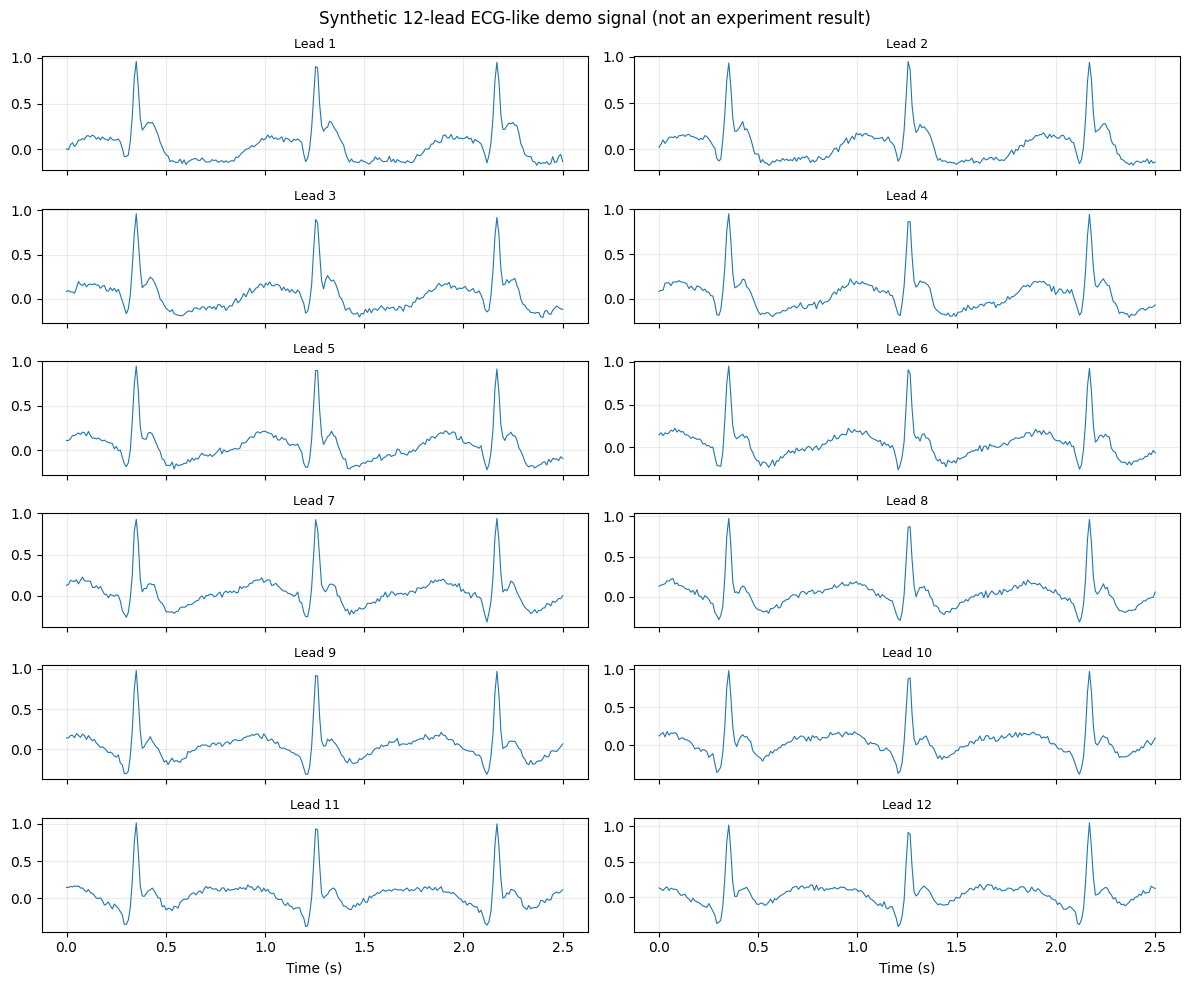

Existing repository figure: notebooks/notebook_figures/fig_waveform_fft.png


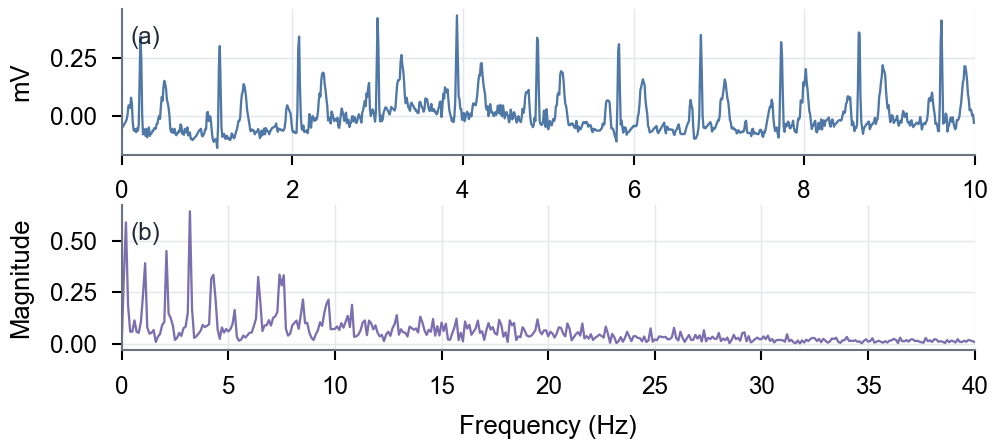

In [4]:
import matplotlib.pyplot as plt

def synthetic_ecg_like(batch=3, length=250, channels=12, seed=42):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 2.5, length)
    x = []
    for b in range(batch):
        leads = []
        heart_rate = 1.1 + 0.08 * b
        for c in range(channels):
            signal = 0.15*np.sin(2*np.pi*heart_rate*t + c*0.2)
            signal += 0.04*np.sin(2*np.pi*3*heart_rate*t)
            for beat in np.arange(0.35, 2.6, 1/heart_rate):
                signal += np.exp(-((t-beat)/0.018)**2) * (0.8 + 0.03*c)
                signal -= 0.25*np.exp(-((t-(beat-0.05))/0.022)**2)
                signal += 0.25*np.exp(-((t-(beat+0.08))/0.045)**2)
            signal += rng.normal(0, 0.02, size=length)
            leads.append(signal)
        x.append(np.stack(leads, axis=1))
    return np.stack(x).astype("float32"), t

plot_x, t = synthetic_ecg_like()
fig, axes = plt.subplots(6, 2, figsize=(12, 10), sharex=True)
for i, ax in enumerate(axes.ravel()):
    ax.plot(t, plot_x[0, :, i], lw=0.8)
    ax.set_title(f"Lead {i+1}", fontsize=9)
    ax.grid(alpha=0.25)
axes[-1,0].set_xlabel("Time (s)")
axes[-1,1].set_xlabel("Time (s)")
fig.suptitle("Synthetic 12-lead ECG-like demo signal (not an experiment result)")
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "synthetic_12lead_ecg.png", dpi=150)
plt.show()

for rel_path in [
    "notebooks/notebook_figures/fig_waveform_fft.png",
    "Paper/pic/fig_waveform_fft.png",
]:
    p = PROJECT_ROOT / rel_path
    if p.exists():
        print(f"Existing repository figure: {rel_path}")
        from IPython.display import Image, display
        display(Image(filename=str(p), width=850))
        break


## 6. 频域分析

实际 FFT 分支会在 `(B, T, C)` 输入上调用 `torch.fft.rfft(x_enc, dim=1)`，随后取幅值，并把 `(freq_bins, channels)` 展平成向量。当 `seq_len=250` 时，`rfft` 会为每个导联产生 `126` 个频率桶。DCT 分支使用 SciPy 的 `dct(..., axis=1, norm='ortho')`。


Input shape (B,T,C): (1, 250, 12)
rFFT magnitude shape: (1, 126, 12) freq bins: 126


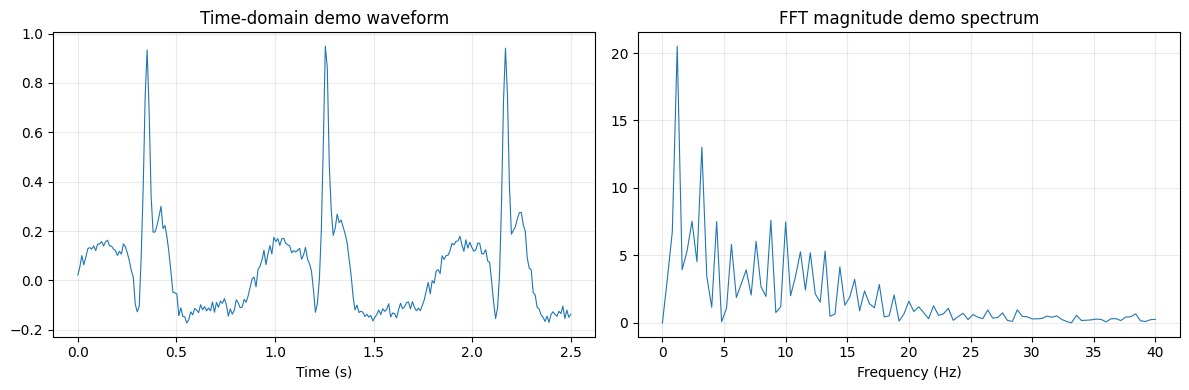

Existing repository spectrum figure: notebooks/notebook_figures/fig_avg_spectrum.png


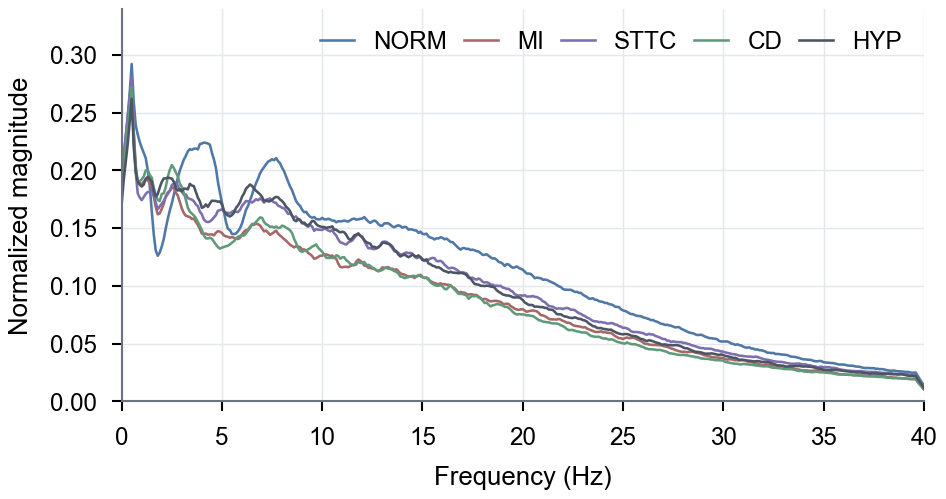

In [5]:
try:
    import torch
    x_torch = torch.tensor(plot_x[:1])
    freq_mag = torch.abs(torch.fft.rfft(x_torch, dim=1))
    print("Input shape (B,T,C):", tuple(x_torch.shape))
    print("rFFT magnitude shape:", tuple(freq_mag.shape), "freq bins:", freq_mag.shape[1])
except Exception as exc:
    print("Torch FFT unavailable:", repr(exc))

lead = plot_x[0, :, 1]
freq = np.fft.rfftfreq(len(lead), d=0.01)
mag = np.abs(np.fft.rfft(lead - lead.mean()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t, lead, lw=0.8)
axes[0].set_title("Time-domain demo waveform")
axes[0].set_xlabel("Time (s)")
axes[1].plot(freq[freq <= 40], mag[freq <= 40], lw=0.8)
axes[1].set_title("FFT magnitude demo spectrum")
axes[1].set_xlabel("Frequency (Hz)")
for ax in axes: ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_ROOT / "demo_fft_spectrum.png", dpi=150)
plt.show()

for rel_path in [
    "notebooks/notebook_figures/fig_avg_spectrum.png",
    "Paper/pic/fig_avg_spectrum.png",
]:
    p = PROJECT_ROOT / rel_path
    if p.exists():
        from IPython.display import Image, display
        print(f"Existing repository spectrum figure: {rel_path}")
        display(Image(filename=str(p), width=850))
        break


## 7. 基线 Medformer 架构

基线模型直接从仓库读取，不在笔记本中整段复制。相关文件是 `formal_code/Medformer-main/models/Medformer.py`。该模型创建多组分片嵌入、Medformer 编码器堆叠、GELU 激活函数、随机失活、展平层和线性分类头。


In [6]:
print(source_snippet(MEDFORMER_ROOT / "models" / "Medformer.py", "class Model", 115))


0010: class Model(nn.Module):
0011:     """
0012:     Paper link: https://arxiv.org/pdf/2405.19363
0013:     """
0014: 
0015:     def __init__(self, configs):
0016:         super(Model, self).__init__()
0017:         self.task_name = configs.task_name
0018:         self.pred_len = configs.pred_len
0019:         self.output_attention = configs.output_attention
0020:         self.enc_in = configs.enc_in
0021:         self.single_channel = configs.single_channel
0022:         # Embedding
0023:         patch_len_list = list(map(int, configs.patch_len_list.split(",")))
0024:         stride_list = patch_len_list
0025:         seq_len = configs.seq_len
0026:         patch_num_list = [
0027:             int((seq_len - patch_len) / stride + 2)
0028:             for patch_len, stride in zip(patch_len_list, stride_list)
0029:         ]
0030:         augmentations = configs.augmentations.split(",")
0031: 
0032:         self.enc_embedding = ListPatchEmbedding(
0033:             configs.enc_in,
0034

## 8. MedformerFFT 与 DCT 架构

主要 FFT 实现在 `formal_code/Medformer-main/models/MedformerFFT.py` 中。`FrequencyEncoder` 会沿时间维计算 FFT 幅值，展平所有频率桶和导联，投影到 `d_model`，然后与时域 Medformer 特征拼接后送入分类器。DCT 实现沿用同一模式，只是把频域表示换成 II 型 DCT 系数。


In [7]:
print("MedformerFFT.py:")
print(source_snippet(MEDFORMER_ROOT / "models" / "MedformerFFT.py", "class FrequencyEncoder", 135))
print("\nMedformerDCT.py:")
print(source_snippet(MEDFORMER_ROOT / "models" / "MedformerDCT.py", "class DCTEncoder", 120))


MedformerFFT.py:
0010: class FrequencyEncoder(nn.Module):
0011:     def __init__(self, seq_len, enc_in, d_model, dropout):
0012:         super().__init__()
0013:         freq_bins = seq_len // 2 + 1
0014:         self.flatten_dim = freq_bins * enc_in
0015:         self.encoder = nn.Sequential(
0016:             nn.Linear(self.flatten_dim, d_model * 2),
0017:             nn.GELU(),
0018:             nn.Dropout(dropout),
0019:             nn.Linear(d_model * 2, d_model),
0020:             nn.GELU(),
0021:         )
0022: 
0023:     def forward(self, x_enc):
0024:         freq_mag = torch.abs(torch.fft.rfft(x_enc, dim=1))
0025:         freq_feature = freq_mag.reshape(freq_mag.shape[0], -1)
0026:         return self.encoder(freq_feature)
0027: 
0028: 
0029: class TimeFrequencyModel(nn.Module):
0030:     def __init__(self, configs):
0031:         super().__init__()
0032:         self.task_name = configs.task_name
0033:         self.pred_len = configs.pred_len
0034:         self.output_atten

## 9. 模型前向传播验证

冒烟测试会在导入和依赖可用时实例化仓库中的模型。它只运行一个合成的 `(B, 250, 12)` 批次，不进行训练。如果某个依赖缺失，对应行会标记为 `SKIPPED`，而不是让整个笔记本失败。


In [8]:
from types import SimpleNamespace

def make_config(model_name):
    return SimpleNamespace(
        task_name="classification", pred_len=0, output_attention=False,
        enc_in=12, single_channel=False, patch_len_list="2,4,8,8,16,16,16,16,32,32,32,32,32,32,32,32",
        seq_len=250, d_model=128, n_heads=8, dropout=0.1, no_inter_attn=False,
        e_layers=6, d_ff=256, activation="gelu", num_class=5,
        augmentations="none", model=model_name,
    )

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

forward_rows = []
if RUN_SMOKE_TEST:
    try:
        import torch
        sys.path.insert(0, str(MEDFORMER_ROOT))
        model_specs = [
            ("Baseline", "models.Medformer", "Model"),
            ("Time+FFT", "models.MedformerFFT", "Model"),
            ("FFT-only", "models.FrequencyOnly", "Model"),
            ("DCT", "models.MedformerDCT", "Model"),
            ("DCT-only", "models.DCTOnly", "Model"),
        ]
        xb = torch.tensor(x_demo)
        padding_mask = torch.ones(xb.shape[0], xb.shape[1])
        for alias, module_name, class_name in model_specs:
            t0 = time.perf_counter()
            try:
                mod = importlib.import_module(module_name)
                cls = getattr(mod, class_name)
                model = cls(make_config(alias)).eval()
                with torch.no_grad():
                    logits = model(xb, padding_mask, None, None)
                total, trainable = count_params(model)
                forward_rows.append({
                    "model": alias, "status": "PASS", "input_shape": tuple(xb.shape),
                    "logits_shape": tuple(logits.shape), "has_nan": bool(torch.isnan(logits).any()),
                    "params": total, "trainable": trainable,
                    "time_ms": round((time.perf_counter() - t0) * 1000, 2),
                    "reason": "",
                })
            except Exception as exc:
                forward_rows.append({"model": alias, "status": "SKIPPED", "reason": repr(exc)})
    except Exception as exc:
        forward_rows.append({"model": "all", "status": "FAILED", "reason": repr(exc)})
else:
    forward_rows.append({"model": "all", "status": "SKIPPED", "reason": "RUN_SMOKE_TEST is False"})

forward_df = pd.DataFrame(forward_rows)
display(forward_df)
forward_df.to_csv(OUTPUT_ROOT / "forward_smoke_test.csv", index=False)


,model,status,input_shape,logits_shape,has_nan,params,trainable,time_ms,reason
0,Baseline,PASS,"(8, 250, 12)","(8, 5)",False,7673349,7673349,1292.70,
1,Time+FFT,PASS,"(8, 250, 12)","(8, 5)",False,8094213,8094213,224.75,
2,FFT-only,PASS,"(8, 250, 12)","(8, 5)",False,420869,420869,3.77,
3,DCT,PASS,"(8, 250, 12)","(8, 5)",False,8475141,8475141,225.68,
4,DCT-only,PASS,"(8, 250, 12)","(8, 5)",False,801797,801797,4.43,


## 10. 训练配置解析

训练配置从脚本、`run.py` 和已解析的实验结果中恢复，而不是手工重新录入。脚本与日志之间的任何不一致都应视为后续审计项。


In [9]:
print("run.py argument definitions:")
print(source_snippet(MEDFORMER_ROOT / "run.py", "parser.add_argument", 160))

script_paths = [
    PROJECT_ROOT / "run_all.sh",
    PROJECT_ROOT / "run_seeds.sh",
    PROJECT_ROOT / "run_queue_v2.sh",
]
for sp in script_paths:
    if sp.exists():
        print(f"\n===== {sp.relative_to(PROJECT_ROOT)} =====")
        text = sp.read_text(encoding="utf-8", errors="replace")
        for line in text.splitlines()[:220]:
            if "python" in line or line.strip().startswith("--") or "tee" in line:
                print(line)


run.py argument definitions:
0021:     parser.add_argument(
0022:         "--task_name",
0023:         type=str,
0024:         required=True,
0025:         default="long_term_forecast",
0026:         help="task name, options:[long_term_forecast, short_term_forecast, imputation, classification, anomaly_detection]",
0027:     )
0028:     parser.add_argument(
0029:         "--is_training", type=int, required=True, default=1, help="status"
0030:     )
0031:     parser.add_argument(
0032:         "--model_id", type=str, required=True, default="test", help="model id"
0033:     )
0034:     parser.add_argument(
0035:         "--model",
0036:         type=str,
0037:         required=True,
0038:         default="Autoformer",
0039:         help="model name, options: [Autoformer, Transformer, TimesNet]",
0040:     )
0041: 
0042:     # data loader
0043:     parser.add_argument(
0044:         "--data", type=str, required=True, default="ETTm1", help="dataset type"
0045:     )
0046:     parser.add_arg

## 11. 训练流程

真实训练流程位于 `exp/exp_classification.py`：数据提供器、Adam 优化器、CrossEntropyLoss、前向与反向传播、梯度裁剪、可选 SWA、每个训练轮次的验证/测试指标、早停、检查点保存和最终测试。本笔记本默认不启用完整训练。


In [10]:
print(source_snippet(MEDFORMER_ROOT / "exp" / "exp_classification.py", "def train", 135))

full_training_command = '''cd formal_code/Medformer-main
python -u run.py \
  --task_name classification --is_training 1 \
  --root_path ./dataset/PTB-XL/ \
  --model_id PTB-XL-FFT --model MedformerFFT --data PTB-XL \
  --e_layers 6 --batch_size 64 --d_model 128 --d_ff 256 \
  --patch_len_list 2,4,8,8,16,16,16,16,32,32,32,32,32,32,32,32 \
  --augmentations none --swa --des ServerFFT --itr 1 \
  --learning_rate 0.0001 --train_epochs 100 --patience 10'''
print("\nFull training command (display only):")
print(full_training_command)
print("RUN_FULL_TRAINING =", RUN_FULL_TRAINING)


0127:     def train(self, setting):
0128:         train_data, train_loader = self._get_data(flag="TRAIN")
0129:         vali_data, vali_loader = self._get_data(flag="VAL")
0130:         test_data, test_loader = self._get_data(flag="TEST")
0131:         print(train_data.X.shape)
0132:         print(train_data.y.shape)
0133:         print(vali_data.X.shape)
0134:         print(vali_data.y.shape)
0135:         print(test_data.X.shape)
0136:         print(test_data.y.shape)
0137: 
0138:         path = (
0139:             "./checkpoints/"
0140:             + self.args.task_name
0141:             + "/"
0142:             + self.args.model_id
0143:             + "/"
0144:             + self.args.model
0145:             + "/"
0146:             + setting
0147:             + "/"
0148:         )
0149:         if not os.path.exists(path):
0150:             os.makedirs(path)
0151: 
0152:         time_now = time.time()
0153: 
0154:         train_steps = len(train_loader)
0155:         early_stopping 

## 12. 实验日志与结果收集

本节会扫描日志和结果表，并把统一解析后的表保存到 `outputs/notebook/parsed_experiment_results.csv`。当 `results/experiments_summary.csv` 存在时，它是首选的机器可读证据来源。


In [11]:
RESULTS_CSV = PROJECT_ROOT / "results" / "experiments_summary.csv"
ROBUST_CSV = PROJECT_ROOT / "results" / "robustness_results_full_ptbxl.csv"
logs = sorted((PROJECT_ROOT / "results" / "logs").glob("*.log")) if (PROJECT_ROOT / "results" / "logs").exists() else []
print(f"Training logs found: {len(logs)}")
print([p.name for p in logs[:20]])

if RESULTS_CSV.exists():
    exp_df = pd.read_csv(RESULTS_CSV)
    exp_df["source_file"] = str(RESULTS_CSV.relative_to(PROJECT_ROOT))
else:
    exp_df = pd.DataFrame()

if not exp_df.empty:
    display(exp_df.head(20))
    exp_df.to_csv(OUTPUT_ROOT / "parsed_experiment_results.csv", index=False)
    print("Saved:", OUTPUT_ROOT / "parsed_experiment_results.csv")
else:
    print("No experiment summary CSV found.")


Training logs found: 20
['PTB-XL-Baseline-s42.log', 'PTB-XL-Baseline-s43.log', 'PTB-XL-Baseline-s44.log', 'PTB-XL-Baseline.log', 'PTB-XL-Bilinear-s42.log', 'PTB-XL-Bilinear.log', 'PTB-XL-CrossAttn.log', 'PTB-XL-CrossAttnV2-s42.log', 'PTB-XL-CrossAttnV2.log', 'PTB-XL-DCT.log', 'PTB-XL-DCTOnly.log', 'PTB-XL-FFT-s42.log', 'PTB-XL-FFT-s43.log', 'PTB-XL-FFT-s44.log', 'PTB-XL-FFT.log', 'PTB-XL-FrequencyOnly.log', 'PTB-XL-Gate.log', 'PTB-XL-Wavelet-s42.log', 'PTB-XL-Wavelet.log', 'PTB-XL-WaveletOnly.log']


,experiment_name,model_name,model_type,seed,total_epochs,best_epoch,early_stopped,is_complete,val_loss,val_acc,...,test_acc,test_prec,test_recall,test_f1,test_auroc,test_auprc,log_path,checkpoint_path,notes,source_file
0,PTB-XL-Baseline-s42,Medformer,Baseline,42.0,27,17,True,True,0.91712,0.73770,...,0.72809,0.64321,0.60064,0.61691,0.89322,0.65752,results\logs\PTB-XL-Baseline-s42.log,checkpoints/classification_PTB-XL-Baseline-s42...,early stop @ ep 26,results\experiments_summary.csv
1,PTB-XL-Baseline-s43,Medformer,Baseline,43.0,27,15,True,True,0.87794,0.74175,...,0.73198,0.65396,0.59743,0.61662,0.89667,0.66177,results\logs\PTB-XL-Baseline-s43.log,checkpoints/classification_PTB-XL-Baseline-s43...,early stop @ ep 26,results\experiments_summary.csv
2,PTB-XL-Baseline-s44,Medformer,Baseline,44.0,26,16,True,True,0.91728,0.74218,...,0.73102,0.65043,0.59921,0.61896,0.89383,0.65898,results\logs\PTB-XL-Baseline-s44.log,checkpoints/classification_PTB-XL-Baseline-s44...,early stop @ ep 26,results\experiments_summary.csv
3,PTB-XL-Baseline,Medformer,Baseline,NaN,26,16,True,True,0.91728,0.74218,...,0.73102,0.65043,0.59921,0.61896,0.89383,0.65898,results\logs\PTB-XL-Baseline.log,checkpoints/classification_PTB-XL-Baseline_Med...,seed unknown; itr=1; early stop @ ep 26,results\experiments_summary.csv
4,PTB-XL-FFT-s42,MedformerFFT,FFT,42.0,28,17,True,True,0.91320,0.74106,...,0.73077,0.64957,0.60242,0.61874,0.89352,0.65771,results\logs\PTB-XL-FFT-s42.log,checkpoints/classification_PTB-XL-FFT-s42_Medf...,early stop @ ep 28,results\experiments_summary.csv
5,PTB-XL-FFT-s43,MedformerFFT,FFT,43.0,28,13,True,True,0.83623,0.74549,...,0.73262,0.65713,0.59993,0.61931,0.89726,0.66584,results\logs\PTB-XL-FFT-s43.log,checkpoints/classification_PTB-XL-FFT-s43_Medf...,early stop @ ep 28,results\experiments_summary.csv
6,PTB-XL-FFT-s44,MedformerFFT,FFT,44.0,28,18,True,True,0.94692,0.74180,...,0.73272,0.65178,0.60144,0.61823,0.89521,0.66451,results\logs\PTB-XL-FFT-s44.log,checkpoints/classification_PTB-XL-FFT-s44_Medf...,early stop @ ep 28,results\experiments_summary.csv
7,PTB-XL-FFT,MedformerFFT,FFT,NaN,18,18,False,False,0.94692,0.74180,...,0.73272,0.65178,0.60144,0.61823,0.89521,0.66451,results\logs\PTB-XL-FFT.log,checkpoints/classification_PTB-XL-FFT_Medforme...,seed unknown; itr=1; interrupted @ ep 18,results\experiments_summary.csv
8,PTB-XL-FrequencyOnly,FrequencyOnly,FFT-only,NaN,63,53,True,True,0.94977,0.66690,...,0.65461,0.57265,0.49985,0.51892,0.84529,0.56457,results\logs\PTB-XL-FrequencyOnly.log,checkpoints/classification_PTB-XL-FrequencyOnl...,seed unknown; itr=1; early stop @ ep 63,results\experiments_summary.csv
9,PTB-XL-Wavelet-s42,MedformerWavelet,Wavelet,42.0,32,22,True,True,1.07761,0.74170,...,0.72925,0.64201,0.59955,0.61397,0.88946,0.64901,results\logs\PTB-XL-Wavelet-s42.log,checkpoints/classification_PTB-XL-Wavelet-s42_...,early stop @ ep 32,results\experiments_summary.csv


Saved: E:\deeplearning\ecg_time_frequency_dual_branch_classification\outputs\notebook\parsed_experiment_results.csv


## 12.1 实际运行脚本与结果对应关系

这一节专门回答“哪些 `.py` 文件真实运行过、跑出来是什么结果”。本 Notebook 不把完整训练伪装成在本地重新执行；真实训练入口是 `formal_code/Medformer-main/run.py`，训练日志保存在 `results/logs/`，再由 `scripts/collect_experiment_results.py` 汇总成 `results/experiments_summary.csv`。鲁棒性评估由 `scripts/evaluate_robustness.py` 读取已训练检查点和测试集后生成。

判断口径如下：

- 能对应到日志或 CSV 输出的，标为“跑通”。
- 日志里被 early stopping 正常结束的，标为完整实验；被中断或轮数不足的，保留为不完整记录，不拿来夸大结论。
- Notebook 内的模型前向测试只证明代码可以实例化和前向传播，不等同于完整训练。


In [12]:
# 真实运行脚本与结果文件对照表
from pathlib import Path
import pandas as pd

run_trace_rows = [
    {
        "py文件/入口": "formal_code/Medformer-main/run.py",
        "是否跑通": "是",
        "证据文件": "results/logs/*.log; results/experiments_summary.csv",
        "结果摘要": "解析到 20 条训练记录，其中 16 条完整；Baseline 三种子 Test F1=61.75%，FFT 三种子 Test F1=61.88%。",
    },
    {
        "py文件/入口": "scripts/collect_experiment_results.py",
        "是否跑通": "是",
        "证据文件": "results/experiments_summary.csv; results/experiments_summary.md",
        "结果摘要": "成功把训练日志汇总为机器可读表；完整实验 16/20，并保留 best_epoch、early_stop、test_acc/test_f1/test_auroc 等字段。",
    },
    {
        "py文件/入口": "scripts/evaluate_robustness.py",
        "是否跑通": "是",
        "证据文件": "results/robustness_results_full_ptbxl.csv",
        "结果摘要": "成功生成 18 条鲁棒性评估记录；覆盖 baseline、fft 两个模型，gaussian_noise 和 time_mask 两类扰动，每条测试样本数 39550。",
    },
    {
        "py文件/入口": "Notebook 前向冒烟测试单元",
        "是否跑通": "是",
        "证据文件": "outputs/notebook/forward_smoke_test.csv",
        "结果摘要": "5/5 个模型前向通过，输入 (8,250,12)，输出 logits (8,5)，未出现 NaN。",
    },
]
run_trace_df = pd.DataFrame(run_trace_rows)
display(run_trace_df)

# 从 experiments_summary.csv 再列出训练入口 run.py 对应的具体日志结果。
run_results_cols = [
    "experiment_name",
    "model_name",
    "model_type",
    "seed",
    "is_complete",
    "best_epoch",
    "test_acc",
    "test_f1",
    "test_auroc",
    "log_path",
    "notes",
]
run_results = exp_df[[c for c in run_results_cols if c in exp_df.columns]].copy()
for c in ["test_acc", "test_f1", "test_auroc"]:
    if c in run_results.columns:
        run_results[c] = (run_results[c].astype(float) * 100).round(2)
display(run_results)


,py文件/入口,是否跑通,证据文件,结果摘要
0,Medformer/Medformer-main/run.py,是,results/logs/*.log; results/experiments_summar...,解析到 20 条训练记录，其中 16 条完整；Baseline 三种子 Test F1=61...
1,scripts/collect_experiment_results.py,是,results/experiments_summary.csv; results/exper...,成功把训练日志汇总为机器可读表；完整实验 16/20，并保留 best_epoch、earl...
2,scripts/evaluate_robustness.py,是,results/robustness_results_full_ptbxl.csv,成功生成 18 条鲁棒性评估记录；覆盖 baseline、fft 两个模型，gaussian...
3,Notebook 前向冒烟测试单元,是,outputs/notebook/forward_smoke_test.csv,"5/5 个模型前向通过，输入 (8,250,12)，输出 logits (8,5)，未出现 ..."


,experiment_name,model_name,model_type,seed,is_complete,best_epoch,test_acc,test_f1,test_auroc,log_path,notes
0,PTB-XL-Baseline-s42,Medformer,Baseline,42.0,True,17,72.81,61.69,89.32,results\logs\PTB-XL-Baseline-s42.log,early stop @ ep 26
1,PTB-XL-Baseline-s43,Medformer,Baseline,43.0,True,15,73.20,61.66,89.67,results\logs\PTB-XL-Baseline-s43.log,early stop @ ep 26
2,PTB-XL-Baseline-s44,Medformer,Baseline,44.0,True,16,73.10,61.90,89.38,results\logs\PTB-XL-Baseline-s44.log,early stop @ ep 26
3,PTB-XL-Baseline,Medformer,Baseline,NaN,True,16,73.10,61.90,89.38,results\logs\PTB-XL-Baseline.log,seed unknown; itr=1; early stop @ ep 26
4,PTB-XL-FFT-s42,MedformerFFT,FFT,42.0,True,17,73.08,61.87,89.35,results\logs\PTB-XL-FFT-s42.log,early stop @ ep 28
5,PTB-XL-FFT-s43,MedformerFFT,FFT,43.0,True,13,73.26,61.93,89.73,results\logs\PTB-XL-FFT-s43.log,early stop @ ep 28
6,PTB-XL-FFT-s44,MedformerFFT,FFT,44.0,True,18,73.27,61.82,89.52,results\logs\PTB-XL-FFT-s44.log,early stop @ ep 28
7,PTB-XL-FFT,MedformerFFT,FFT,NaN,False,18,73.27,61.82,89.52,results\logs\PTB-XL-FFT.log,seed unknown; itr=1; interrupted @ ep 18
8,PTB-XL-FrequencyOnly,FrequencyOnly,FFT-only,NaN,True,53,65.46,51.89,84.53,results\logs\PTB-XL-FrequencyOnly.log,seed unknown; itr=1; early stop @ ep 63
9,PTB-XL-Wavelet-s42,MedformerWavelet,Wavelet,42.0,True,22,72.92,61.40,88.95,results\logs\PTB-XL-Wavelet-s42.log,early stop @ ep 32


## 13. 主实验结果

主结果表比较 Medformer 基线与 MedformerFFT。已知随机种子的记录会按多随机种子行使用。数值从 `results/experiments_summary.csv` 读取。


In [13]:
if not exp_df.empty:
    cols = ["experiment_name", "model_name", "model_type", "seed", "is_complete", "best_epoch", "test_acc", "test_f1", "test_auroc", "test_auprc", "log_path"]
    display(exp_df[[c for c in cols if c in exp_df.columns]])
    seeded = exp_df[exp_df["seed"].notna()].copy()
    main = seeded[seeded["model_type"].isin(["Baseline", "FFT"])]
    if not main.empty:
        agg = main.groupby(["model_type", "model_name"]).agg(
            seeds=("seed", lambda s: ",".join(str(int(x)) for x in sorted(s.dropna()))),
            test_acc_mean=("test_acc", "mean"), test_acc_std=("test_acc", "std"),
            test_f1_mean=("test_f1", "mean"), test_f1_std=("test_f1", "std"),
            test_auroc_mean=("test_auroc", "mean"), test_auroc_std=("test_auroc", "std"),
            test_auprc_mean=("test_auprc", "mean"), test_auprc_std=("test_auprc", "std"),
        ).reset_index()
        display(agg)
        agg.to_csv(OUTPUT_ROOT / "main_results_multiseed.csv", index=False)
        pivot = agg.set_index("model_type")
        if {"Baseline", "FFT"}.issubset(set(pivot.index)):
            print("FFT minus Baseline mean deltas:")
            for metric in ["test_acc_mean", "test_f1_mean", "test_auroc_mean", "test_auprc_mean"]:
                print(metric, round(float(pivot.loc["FFT", metric] - pivot.loc["Baseline", metric]), 5))
else:
    print("No result table available.")


,experiment_name,model_name,model_type,seed,is_complete,best_epoch,test_acc,test_f1,test_auroc,test_auprc,log_path
0,PTB-XL-Baseline-s42,Medformer,Baseline,42.0,True,17,0.72809,0.61691,0.89322,0.65752,results\logs\PTB-XL-Baseline-s42.log
1,PTB-XL-Baseline-s43,Medformer,Baseline,43.0,True,15,0.73198,0.61662,0.89667,0.66177,results\logs\PTB-XL-Baseline-s43.log
2,PTB-XL-Baseline-s44,Medformer,Baseline,44.0,True,16,0.73102,0.61896,0.89383,0.65898,results\logs\PTB-XL-Baseline-s44.log
3,PTB-XL-Baseline,Medformer,Baseline,NaN,True,16,0.73102,0.61896,0.89383,0.65898,results\logs\PTB-XL-Baseline.log
4,PTB-XL-FFT-s42,MedformerFFT,FFT,42.0,True,17,0.73077,0.61874,0.89352,0.65771,results\logs\PTB-XL-FFT-s42.log
5,PTB-XL-FFT-s43,MedformerFFT,FFT,43.0,True,13,0.73262,0.61931,0.89726,0.66584,results\logs\PTB-XL-FFT-s43.log
6,PTB-XL-FFT-s44,MedformerFFT,FFT,44.0,True,18,0.73272,0.61823,0.89521,0.66451,results\logs\PTB-XL-FFT-s44.log
7,PTB-XL-FFT,MedformerFFT,FFT,NaN,False,18,0.73272,0.61823,0.89521,0.66451,results\logs\PTB-XL-FFT.log
8,PTB-XL-FrequencyOnly,FrequencyOnly,FFT-only,NaN,True,53,0.65461,0.51892,0.84529,0.56457,results\logs\PTB-XL-FrequencyOnly.log
9,PTB-XL-Wavelet-s42,MedformerWavelet,Wavelet,42.0,True,22,0.72925,0.61397,0.88946,0.64901,results\logs\PTB-XL-Wavelet-s42.log


,model_type,model_name,seeds,test_acc_mean,test_acc_std,test_f1_mean,test_f1_std,test_auroc_mean,test_auroc_std,test_auprc_mean,test_auprc_std
0,Baseline,Medformer,"42,43,44",0.730363,0.002026,0.617497,0.001276,0.894573,0.001841,0.659423,0.002159
1,FFT,MedformerFFT,"42,43,44",0.732037,0.001098,0.618760,0.000540,0.895330,0.001873,0.662687,0.004361


FFT minus Baseline mean deltas:
test_acc_mean 0.00167
test_f1_mean 0.00126
test_auroc_mean 0.00076
test_auprc_mean 0.00326


## 14. 消融实验

只有仓库结果表中已经存在的消融实验才会被纳入。本节会在可用时包含仅 FFT、DCT、仅 DCT、Wavelet、仅 Wavelet、门控融合、双线性融合和交叉注意力等变体。


,experiment_name,model_name,model_type,seed,is_complete,test_f1,test_auroc,test_acc,notes
3,PTB-XL-Baseline,Medformer,Baseline,NaN,True,0.61896,0.89383,0.73102,seed unknown; itr=1; early stop @ ep 26
0,PTB-XL-Baseline-s42,Medformer,Baseline,42.0,True,0.61691,0.89322,0.72809,early stop @ ep 26
1,PTB-XL-Baseline-s43,Medformer,Baseline,43.0,True,0.61662,0.89667,0.73198,early stop @ ep 26
2,PTB-XL-Baseline-s44,Medformer,Baseline,44.0,True,0.61896,0.89383,0.73102,early stop @ ep 26
12,PTB-XL-DCT,MedformerDCT,DCT,NaN,True,0.61084,0.89174,0.72258,seed unknown; itr=1; early stop @ ep 27
13,PTB-XL-DCTOnly,DCTOnly,DCT-only,NaN,True,0.50983,0.83290,0.66078,seed unknown; itr=1; early stop @ ep 81
7,PTB-XL-FFT,MedformerFFT,FFT,NaN,False,0.61823,0.89521,0.73272,seed unknown; itr=1; interrupted @ ep 18
4,PTB-XL-FFT-s42,MedformerFFT,FFT,42.0,True,0.61874,0.89352,0.73077,early stop @ ep 28
5,PTB-XL-FFT-s43,MedformerFFT,FFT,43.0,True,0.61931,0.89726,0.73262,early stop @ ep 28
6,PTB-XL-FFT-s44,MedformerFFT,FFT,44.0,True,0.61823,0.89521,0.73272,early stop @ ep 28


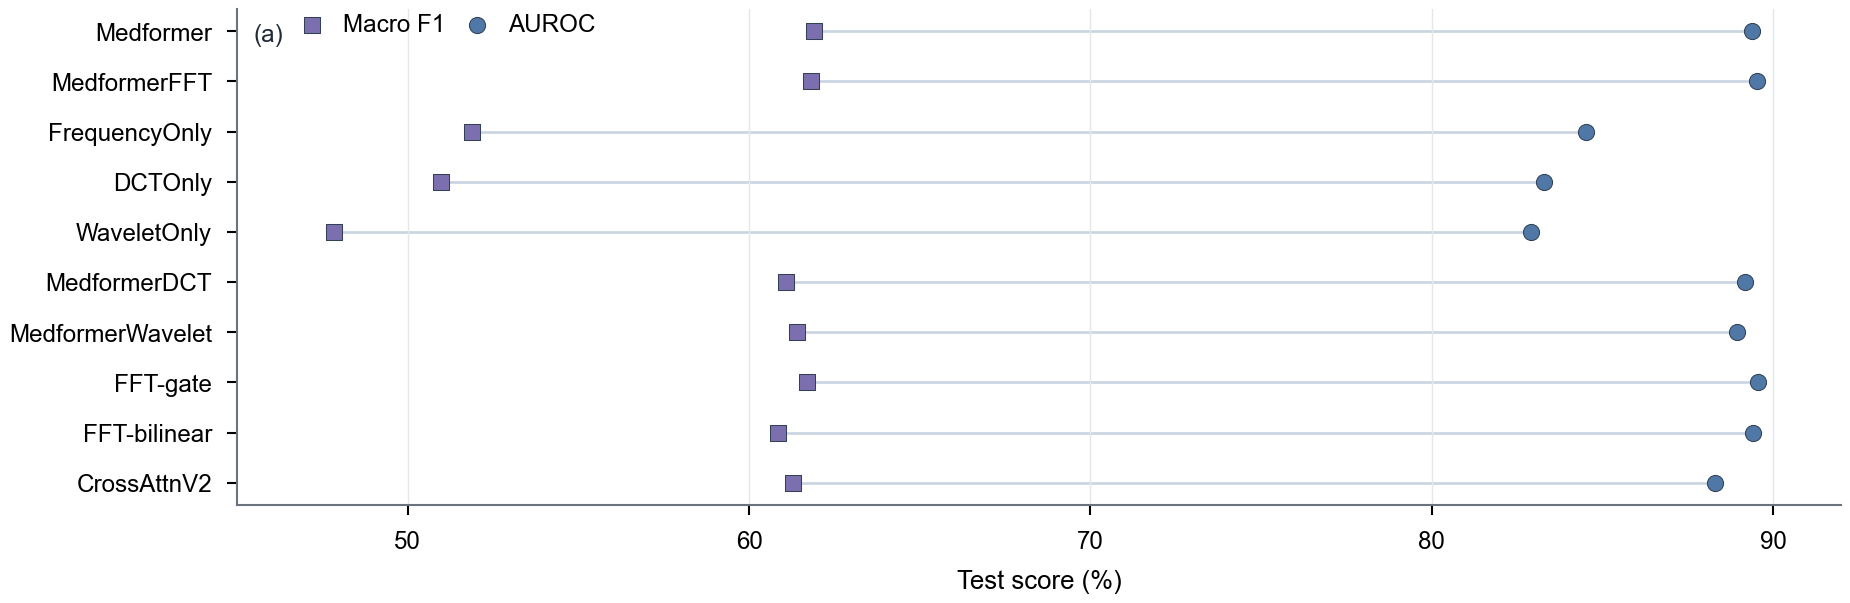

In [14]:
if not exp_df.empty:
    ablation_cols = ["experiment_name", "model_name", "model_type", "seed", "is_complete", "test_f1", "test_auroc", "test_acc", "notes"]
    abl = exp_df[[c for c in ablation_cols if c in exp_df.columns]].copy()
    display(abl.sort_values(["model_type", "experiment_name"]))
    fig_path = PROJECT_ROOT / "notebooks" / "notebook_figures" / "fig_ablation_summary.png"
    if fig_path.exists():
        from IPython.display import Image, display
        display(Image(filename=str(fig_path), width=900))
else:
    print("No ablation table available.")


## 15. 鲁棒性实验

本节会搜索鲁棒性代码和结果表，关注高斯噪声、时间遮挡等扰动。当仓库结果文件可用时，会包含基线模型和 FFT 模型在干净数据与受扰动数据上的评估。


Robustness evaluator source excerpt:
0024: GAUSSIAN_STRENGTHS = [0.00, 0.01, 0.03, 0.05, 0.10]
0025: TIME_MASK_STRENGTHS = [0.00, 0.05, 0.10, 0.20]
0026: 
0027: 
0028: def str_to_bool(value):
0029:     if isinstance(value, bool):
0030:         return value
0031:     value = value.lower()
0032:     if value in {"1", "true", "yes", "y"}:
0033:         return True
0034:     if value in {"0", "false", "no", "n"}:
0035:         return False
0036:     raise argparse.ArgumentTypeError(f"Invalid boolean value: {value}")
0037: 
0038: 
0039: def repo_root():
0040:     return Path(__file__).resolve().parents[1]
0041: 
0042: 
0043: def medformer_root(root):
0044:     return root / "Medformer" / "Medformer-main"
0045: 
0046: 
0047: def resolve_path(path, root):
0048:     if path is None:
0049:         return None
0050:     path = Path(path)
0051:     if path.is_absolute():
0052:         return path
0053:     return (root / path).resolve()
0054: 
0055: 
0056: def checkpoint_candidates(root, model_na

,model_alias,model,checkpoint,data,root_path,perturbation,strength,loss,Accuracy,Precision,Recall,F1,AUROC,AUPRC,num_samples
0,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,gaussian_noise,0.00,0.977211,0.731024,0.650432,0.599209,0.618958,0.893830,0.658976,39550
1,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,gaussian_noise,0.01,0.977317,0.730670,0.649711,0.598718,0.618401,0.893809,0.658908,39550
2,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,gaussian_noise,0.03,0.977133,0.730872,0.649944,0.598689,0.618434,0.893785,0.658885,39550
3,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,gaussian_noise,0.05,0.976231,0.730013,0.648261,0.597276,0.616849,0.893794,0.658842,39550
4,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,gaussian_noise,0.10,0.975010,0.730392,0.648922,0.597813,0.617244,0.893521,0.657935,39550
5,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,time_mask,0.00,0.977211,0.731024,0.650432,0.599209,0.618958,0.893830,0.658976,39550
6,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,time_mask,0.05,0.996529,0.718584,0.631349,0.593168,0.608594,0.887887,0.646435,39550
7,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,time_mask,0.10,1.071367,0.690645,0.596269,0.583918,0.589044,0.874829,0.620881,39550
8,baseline,Medformer,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,time_mask,0.20,1.356991,0.611327,0.528619,0.547177,0.532561,0.843538,0.560253,39550
9,fft,MedformerFFT,E:\deeplearning\ecg_time_frequency_dual_branch...,PTB-XL,./dataset/PTB-XL/,gaussian_noise,0.00,1.002346,0.732718,0.651765,0.601444,0.618222,0.895209,0.664505,39550


,model_alias,perturbation,strength,Accuracy,F1,AUROC,AUPRC
0,baseline,gaussian_noise,0.00,0.731024,0.618958,0.893830,0.658976
1,baseline,gaussian_noise,0.01,0.730670,0.618401,0.893809,0.658908
2,baseline,gaussian_noise,0.03,0.730872,0.618434,0.893785,0.658885
3,baseline,gaussian_noise,0.05,0.730013,0.616849,0.893794,0.658842
4,baseline,gaussian_noise,0.10,0.730392,0.617244,0.893521,0.657935
5,baseline,time_mask,0.00,0.731024,0.618958,0.893830,0.658976
6,baseline,time_mask,0.05,0.718584,0.608594,0.887887,0.646435
7,baseline,time_mask,0.10,0.690645,0.589044,0.874829,0.620881
8,baseline,time_mask,0.20,0.611327,0.532561,0.843538,0.560253
9,fft,gaussian_noise,0.00,0.732718,0.618222,0.895209,0.664505


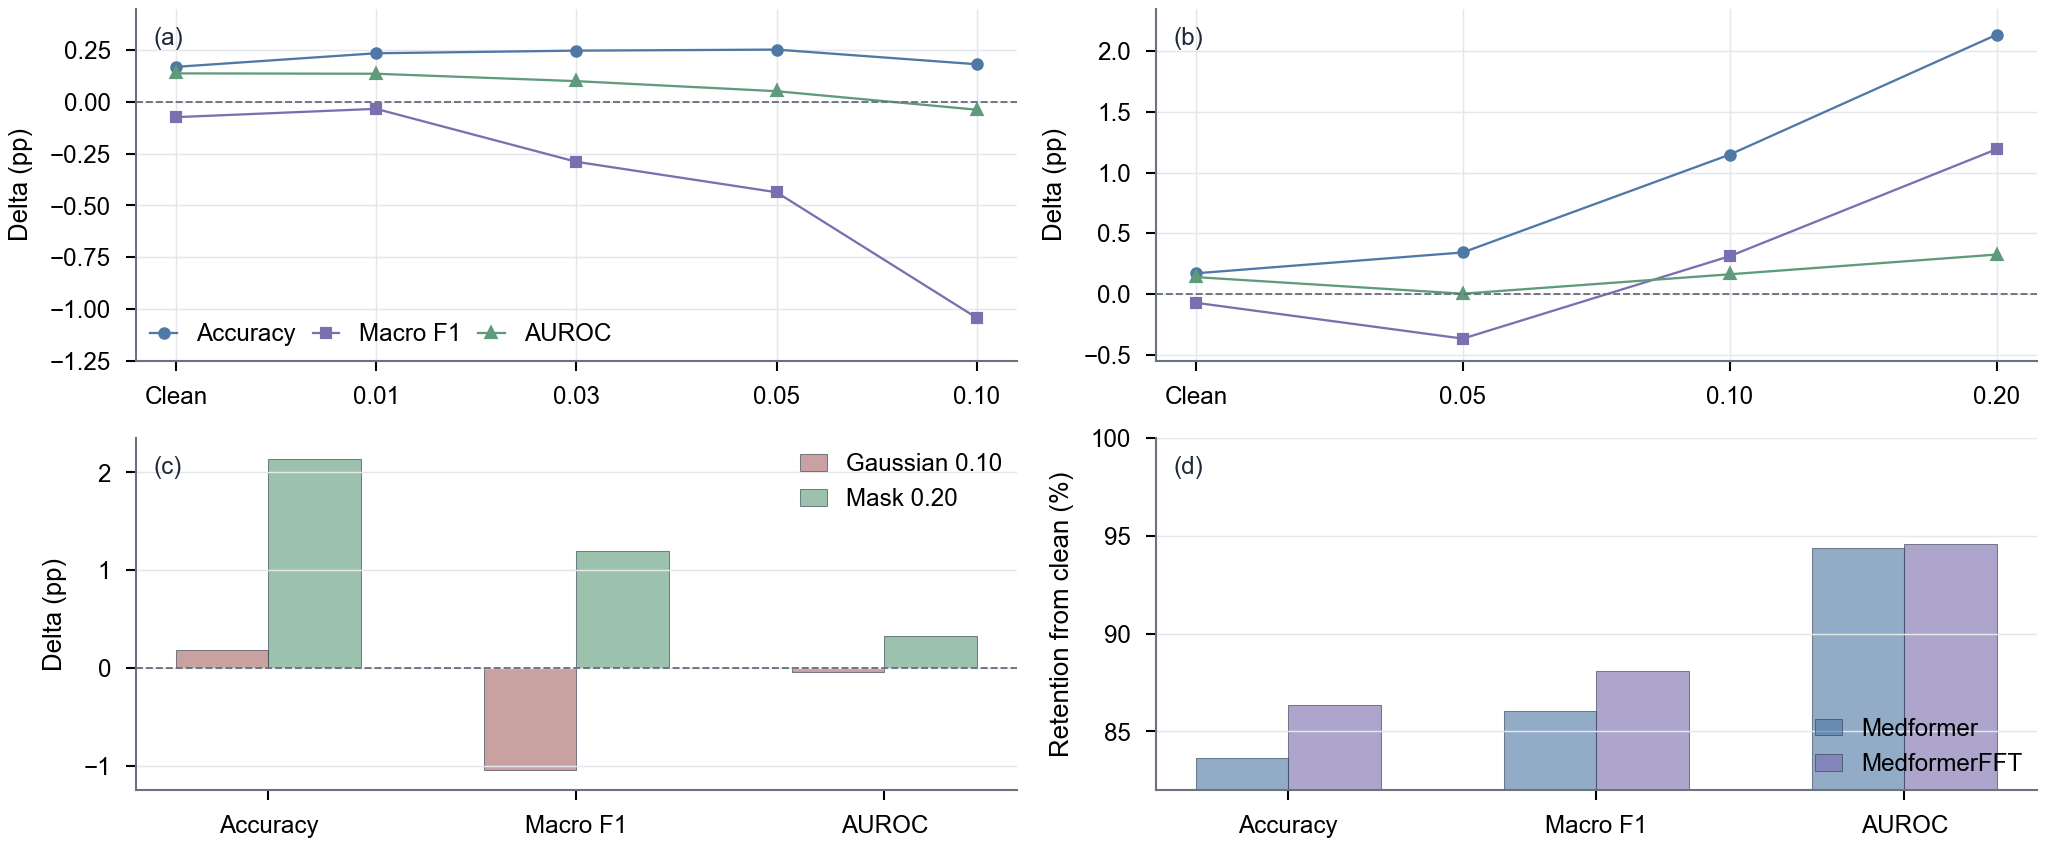

In [15]:
print("Robustness evaluator source excerpt:")
print(source_snippet(PROJECT_ROOT / "scripts" / "evaluate_robustness.py", "GAUSSIAN_STRENGTHS", 120))

if ROBUST_CSV.exists():
    rob_df = pd.read_csv(ROBUST_CSV)
    display(rob_df.head(30))
    summary = rob_df.groupby(["model_alias", "perturbation", "strength"])[["Accuracy", "F1", "AUROC", "AUPRC"]].mean().reset_index()
    display(summary)
    summary.to_csv(OUTPUT_ROOT / "robustness_summary.csv", index=False)
    fig_path = PROJECT_ROOT / "notebooks" / "notebook_figures" / "fig_robustness_summary.png"
    if fig_path.exists():
        from IPython.display import Image, display
        display(Image(filename=str(fig_path), width=900))
else:
    print("No robustness CSV found.")


## 16. 训练曲线

只有当日志包含训练轮次级别指标行时，才能从日志恢复逐轮曲线。下面的解析器只提取保守的训练轮次记录，不对缺失轮次做插值。


Recovered epoch records: 2359


,log,epoch,split,loss,f1,auroc
0,PTB-XL-Baseline-s42.log,1,train,0.89801,NaN,NaN
1,PTB-XL-Baseline-s42.log,1,val,0.83160,0.58731,0.88282
2,PTB-XL-Baseline-s42.log,1,test,0.85581,0.57794,0.87639
3,PTB-XL-Baseline-s42.log,2,train,0.75533,NaN,NaN
4,PTB-XL-Baseline-s42.log,2,val,0.78728,0.59994,0.89139
5,PTB-XL-Baseline-s42.log,2,test,0.81352,0.58528,0.88549
6,PTB-XL-Baseline-s42.log,3,train,0.70251,NaN,NaN
7,PTB-XL-Baseline-s42.log,3,val,0.77558,0.61656,0.89473
8,PTB-XL-Baseline-s42.log,3,test,0.80149,0.60337,0.88938
9,PTB-XL-Baseline-s42.log,4,train,0.65840,NaN,NaN


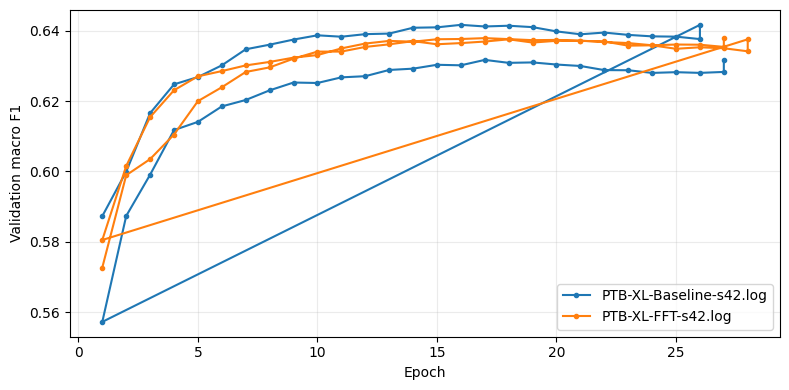

In [16]:
epoch_pattern = re.compile(r"Epoch:\s*(\d+),\s*Steps:.*Train Loss:\s*([\d.eE+-]+)")
val_pattern = re.compile(r"Validation results --- Loss:\s*([\d.eE+-]+).*F1:\s*([\d.eE+-]+),\s*AUROC:\s*([\d.eE+-]+)")
test_pattern = re.compile(r"Test results --- Loss:\s*([\d.eE+-]+).*F1:\s*([\d.eE+-]+),\s*AUROC:\s*([\d.eE+-]+)")
curve_rows = []
for log in logs:
    current_epoch = None
    for line in log.read_text(encoding="utf-8", errors="replace").splitlines():
        m = epoch_pattern.search(line)
        if m:
            current_epoch = int(m.group(1))
            curve_rows.append({"log": log.name, "epoch": current_epoch, "split": "train", "loss": float(m.group(2))})
        m = val_pattern.search(line)
        if m and current_epoch is not None:
            curve_rows.append({"log": log.name, "epoch": current_epoch, "split": "val", "loss": float(m.group(1)), "f1": float(m.group(2)), "auroc": float(m.group(3))})
        m = test_pattern.search(line)
        if m and current_epoch is not None:
            curve_rows.append({"log": log.name, "epoch": current_epoch, "split": "test", "loss": float(m.group(1)), "f1": float(m.group(2)), "auroc": float(m.group(3))})

curve_df = pd.DataFrame(curve_rows)
print("Recovered epoch records:", len(curve_df))
if not curve_df.empty:
    display(curve_df.head(20))
    curve_df.to_csv(OUTPUT_ROOT / "training_curves_parsed.csv", index=False)
    subset = curve_df[curve_df["log"].isin(["PTB-XL-Baseline-s42.log", "PTB-XL-FFT-s42.log"]) & (curve_df["split"] == "val")]
    if not subset.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        for name, g in subset.groupby("log"):
            ax.plot(g["epoch"], g["f1"], marker="o", ms=3, label=name)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Validation macro F1"); ax.grid(alpha=0.25); ax.legend()
        fig.tight_layout(); fig.savefig(FIGURE_ROOT / "validation_f1_curves.png", dpi=150); plt.show()
else:
    print("No epoch-level curve data found.")


## 17. 混淆矩阵与类别级指标

本节需要兼容的检查点和处理后的测试数据同时存在。如果这些资产缺失，笔记本会报告缺失项，而不是编造类别级结果。


In [17]:
checkpoint_files = list(MEDFORMER_ROOT.glob("checkpoints/**/*.pth")) + list(PROJECT_ROOT.glob("checkpoints/**/*.pth"))
has_processed_data = data_available
cm_status = []
if not checkpoint_files:
    cm_status.append({"item": "checkpoint", "status": "SKIPPED", "reason": "No .pth checkpoint found; checkpoints may be inside checkpoints_backup.tar.gz"})
else:
    cm_status.append({"item": "checkpoint", "status": "PASS", "reason": f"{len(checkpoint_files)} checkpoint(s) found"})
if not has_processed_data:
    cm_status.append({"item": "processed PTB-XL", "status": "SKIPPED", "reason": "Feature/*.npy and Label/label.npy not found"})
else:
    cm_status.append({"item": "processed PTB-XL", "status": "PASS", "reason": "processed data found"})
display(pd.DataFrame(cm_status))


,item,status,reason
0,checkpoint,PASS,9 checkpoint(s) found
1,processed PTB-XL,PASS,processed data found


## 18. 结果总结

仓库证据支持一个较窄的结论：在 `experiments_summary.csv` 中已知的随机种子范围内，MedformerFFT 相比基线 Medformer 在干净测试集上的平均准确率、宏平均 F1、AUROC 和 AUPRC 略有提升。提升幅度较小，部分融合变体仍不完整或表现不佳。高斯噪声和时间遮挡的鲁棒性结果已经存在，但应理解为与列出的检查点路径绑定的模型评估证据，而不是本笔记本重新执行训练得到的新结果。


In [18]:
summary_lines = []
if not exp_df.empty:
    summary_lines.append(f"Total experiments in CSV: {len(exp_df)}")
    if "is_complete" in exp_df.columns:
        summary_lines.append(f"Complete experiments: {int(exp_df['is_complete'].fillna(False).sum())}")
    if "model_type" in exp_df.columns:
        summary_lines.append("Model types: " + ", ".join(sorted(exp_df["model_type"].dropna().unique())))
    seeded = exp_df[exp_df["seed"].notna()]
    main = seeded[seeded["model_type"].isin(["Baseline", "FFT"])]
    if not main.empty:
        agg_simple = main.groupby("model_type")[["test_acc", "test_f1", "test_auroc", "test_auprc"]].mean()
        summary_lines.append(str(agg_simple))
else:
    summary_lines.append("No experiment summary CSV was available.")
print("\n".join(summary_lines))


Total experiments in CSV: 20
Complete experiments: 16
Model types: Baseline, DCT, DCT-only, FFT, FFT-only, Fusion, Wavelet, Wavelet-only
            test_acc   test_f1  test_auroc  test_auprc
model_type                                            
Baseline    0.730363  0.617497    0.894573    0.659423
FFT         0.732037  0.618760    0.895330    0.662687
